In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import ast
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

# Estilo global
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
# Rutas
RAW = '../data/raw/'

# Carga
movies = pd.read_csv(RAW + 'tmdb_5000_movies.csv')
credits = pd.read_csv(RAW + 'tmdb_5000_credits.csv')

# Inspección inicial
print("MOVIES:", movies.shape)
print("CREDITS:", credits.shape)
print("\n--- MOVIES columns ---")
print(movies.columns.tolist())
print("\n--- CREDITS columns ---")
print(credits.columns.tolist())

MOVIES: (4803, 20)
CREDITS: (4803, 4)

--- MOVIES columns ---
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

--- CREDITS columns ---
['movie_id', 'title', 'cast', 'crew']


In [4]:
# Eliminamos el título duplicado de credits antes del merge
credits.drop(columns=['title'], inplace=True)

# Merge por clave común
df = movies.merge(credits, left_on='id', right_on='movie_id')

# Eliminamos movie_id (ya tenemos id)
df.drop(columns=['movie_id'], inplace=True)

# Verificación
print("Shape tras merge:", df.shape)
print("Columnas:", df.columns.tolist())

Shape tras merge: (4803, 22)
Columnas: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'cast', 'crew']


In [5]:
# Tipos de datos
print("--- TIPOS ---")
print(df.dtypes)

# Nulos
print("\n--- NULOS ---")
nulos = df.isnull().sum()
print(nulos[nulos > 0])

# Duplicados
print("\n--- DUPLICADOS ---")
print("Filas duplicadas:", df.duplicated().sum())

--- TIPOS ---
budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
vote_count                int64
cast                     object
crew                     object
dtype: object

--- NULOS ---
homepage        3091
overview           3
release_date       1
runtime            2
tagline          844
dtype: int64

--- DUPLICADOS ---
Filas duplicadas: 0


In [6]:
# Eliminamos columnas sin valor predictivo
df.drop(columns=['homepage', 'tagline'], inplace=True)

# Imputamos runtime con la mediana
df['runtime'].fillna(df['runtime'].median(), inplace=True)

# Verificación
print("Shape tras limpieza:", df.shape)
print("\nNulos restantes:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape tras limpieza: (4803, 20)

Nulos restantes:
overview        3
release_date    1
dtype: int64


In [7]:
# Columnas con formato JSON embebido
json_cols = ['genres', 'keywords', 'production_companies', 
             'production_countries', 'spoken_languages', 'cast', 'crew']

# Parseamos cada una de string a lista de dicts
for col in json_cols:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])

# Verificación
print("Ejemplo genres:", df['genres'][0])
print("\nEjemplo cast:", df['cast'][0][:2])
print("\nEjemplo crew:", df['crew'][0][:2])

Ejemplo genres: [{'id': 28, 'name': 'Action'}, {'id': 12, 'name': 'Adventure'}, {'id': 14, 'name': 'Fantasy'}, {'id': 878, 'name': 'Science Fiction'}]

Ejemplo cast: [{'cast_id': 242, 'character': 'Jake Sully', 'credit_id': '5602a8a7c3a3685532001c9a', 'gender': 2, 'id': 65731, 'name': 'Sam Worthington', 'order': 0}, {'cast_id': 3, 'character': 'Neytiri', 'credit_id': '52fe48009251416c750ac9cb', 'gender': 1, 'id': 8691, 'name': 'Zoe Saldana', 'order': 1}]

Ejemplo crew: [{'credit_id': '52fe48009251416c750aca23', 'department': 'Editing', 'gender': 0, 'id': 1721, 'job': 'Editor', 'name': 'Stephen E. Rivkin'}, {'credit_id': '539c47ecc3a36810e3001f87', 'department': 'Art', 'gender': 2, 'id': 496, 'job': 'Production Design', 'name': 'Rick Carter'}]


In [8]:
# Géneros y keywords como listas de nombres
df['genres'] = df['genres'].apply(lambda x: [d['name'] for d in x])
df['keywords'] = df['keywords'].apply(lambda x: [d['name'] for d in x])

# Productora principal
df['main_production_company'] = df['production_companies'].apply(
    lambda x: x[0]['name'] if len(x) > 0 else np.nan)

# Top 3 actores
df['top_cast'] = df['cast'].apply(
    lambda x: [d['name'] for d in sorted(x, key=lambda k: k['order'])[:3]])

# Director extraído de crew
df['director'] = df['crew'].apply(
    lambda x: next((d['name'] for d in x if d['job'] == 'Director'), np.nan))

# Verificación
print("Genres ejemplo:", df['genres'][0])
print("Keywords ejemplo:", df['keywords'][0][:3])
print("Productora principal:", df['main_production_company'][0])
print("Top cast:", df['top_cast'][0])
print("Director:", df['director'][0])

Genres ejemplo: ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
Keywords ejemplo: ['culture clash', 'future', 'space war']
Productora principal: Ingenious Film Partners
Top cast: ['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver']
Director: James Cameron


In [9]:
# Eliminamos solo las columnas raw que ya fueron reemplazadas por versiones procesadas
# genres y keywords YA fueron sobreescritas en celda 7, no se eliminan
df.drop(columns=['production_companies', 'production_countries', 
                 'spoken_languages', 'cast', 'crew'], inplace=True)

# Verificación
print("Shape:", df.shape)
print("Columnas:", df.columns.tolist())

Shape: (4803, 18)
Columnas: ['budget', 'genres', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'release_date', 'revenue', 'runtime', 'status', 'title', 'vote_average', 'vote_count', 'main_production_company', 'top_cast', 'director']


In [10]:
# Extraemos año y mes de release_date
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

# Eliminamos filas con budget o revenue = 0 (datos ausentes disfrazados)
df = df[(df['budget'] > 0) & (df['revenue'] > 0)]

# Variable target: 1 si la película recupera su presupuesto
df['success'] = (df['revenue'] > df['budget']).astype(int)

# Verificación
print("Shape tras filtrar zeros:", df.shape)
print("\nDistribución del target:")
print(df['success'].value_counts())
print("\nBalance (%):")
print(df['success'].value_counts(normalize=True).round(2))

Shape tras filtrar zeros: (3229, 21)

Distribución del target:
success
1    2438
0     791
Name: count, dtype: int64

Balance (%):
success
1    0.76
0    0.24
Name: proportion, dtype: float64


In [11]:
# Ruta de destino
PROCESSED = '../data/processed/'
os.makedirs(PROCESSED, exist_ok=True)

# Guardamos el dataframe limpio
df.to_pickle(PROCESSED + 'df_clean.pkl')

# Verificación: recargamos y comprobamos que es idéntico
df_check = pd.read_pickle(PROCESSED + 'df_clean.pkl')
print("Shape original:", df.shape)
print("Shape desde pickle:", df_check.shape)
print("Son idénticos:", df.equals(df_check))

Shape original: (3229, 21)
Shape desde pickle: (3229, 21)
Son idénticos: True


## ANALISIS DE VARIABLES

#### BUDGET

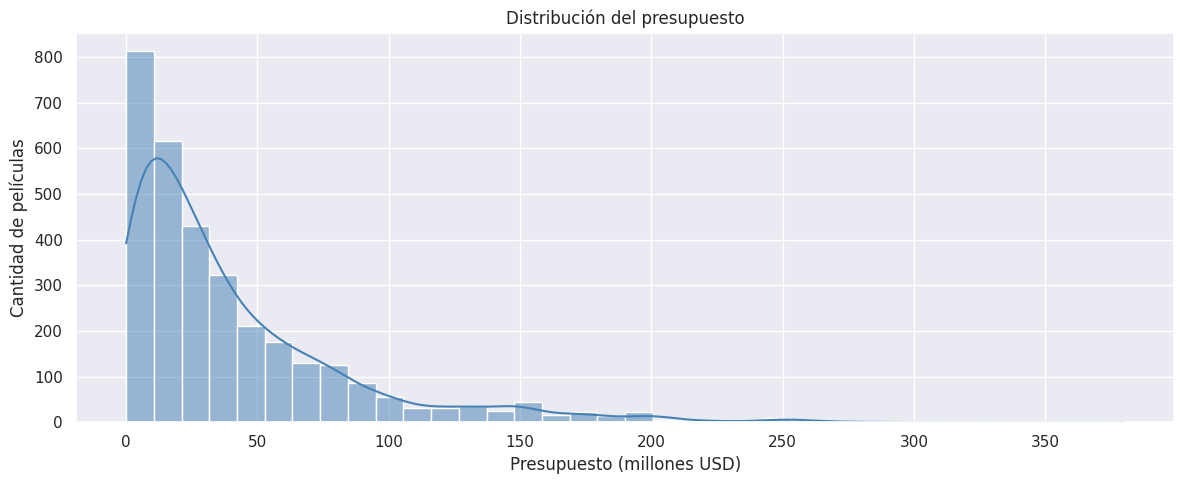

In [19]:
# Convertimos a millones para legibilidad
budget_m = df['budget'] / 1_000_000

# --- Distribución general del presupuesto ---
fig, ax = plt.subplots()
sns.histplot(budget_m, bins=36, kde=True, color='steelblue', ax=ax)
ax.set_title('Distribución del presupuesto')
ax.set_xlabel('Presupuesto (millones USD)')
ax.set_ylabel('Cantidad de películas')
plt.tight_layout()
plt.show()

# --- Presupuesto vs target ---
df_plot = df.copy()
df_plot['budget_m'] = df_plot['budget'] / 1_000_000

fig = px.box(df_plot, x='success', y='budget_m',
             color='success',
             labels={'success': 'Éxito', 'budget_m': 'Presupuesto (millones USD)'},
             title='Presupuesto según éxito o fracaso',
             color_discrete_map={0: '#e74c3c', 1: '#2ecc71'})
fig.update_layout(showlegend=False)
fig.show()

### 💰 Presupuesto
La distribución es asimétrica positiva con alta concentración entre 10M y 30M USD.
Las medianas de éxito y fracaso son casi idénticas (27M vs 24M), lo que indica que
el presupuesto medio no discrimina el éxito por sí solo. La divergencia aparece en
el rango alto (Q3: 60M éxito vs 45M fracaso), sugiriendo que presupuestos elevados
correlacionan moderadamente con el éxito, pero no son determinantes.
**Implicación para el modelo:** feature útil pero de poder predictivo moderado en rangos medios.

#### DURACIÓN

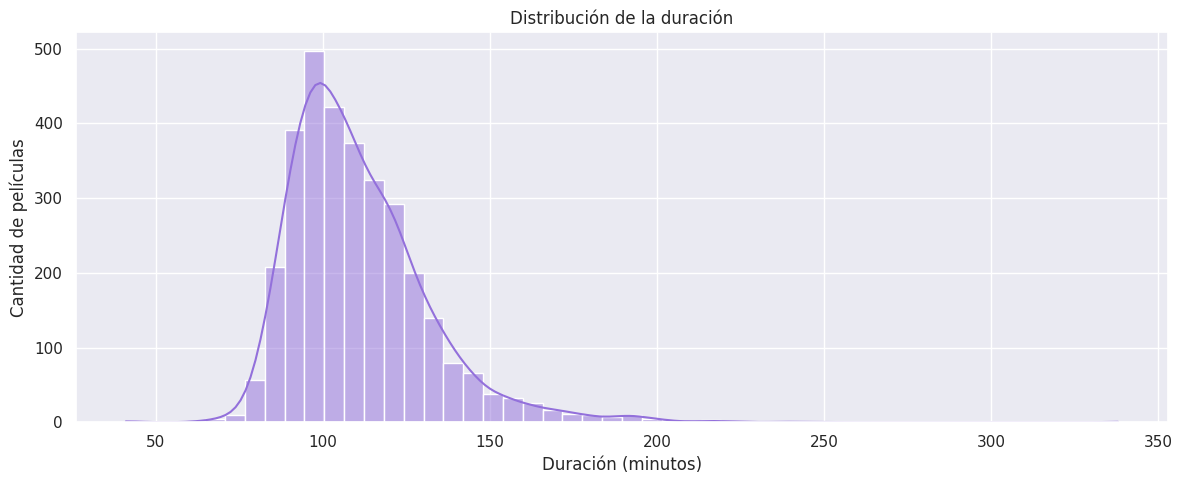

In [21]:
# --- Distribución general del runtime ---
fig, ax = plt.subplots()
sns.histplot(df['runtime'], bins=50, kde=True, color='mediumpurple', ax=ax)
ax.set_title('Distribución de la duración')
ax.set_xlabel('Duración (minutos)')
ax.set_ylabel('Cantidad de películas')
plt.tight_layout()
plt.show()

# --- Runtime vs target ---
fig = px.violin(df, x='success', y='runtime',
                color='success',
                box=True,
                labels={'success': 'Éxito', 'runtime': 'Duración (minutos)'},
                title='Duración según éxito o fracaso',
                color_discrete_map={0: '#e74c3c', 1: '#2ecc71'})
fig.update_layout(showlegend=False)
fig.show()

### 🎬 Duración
Distribución aproximadamente normal centrada en ~100 minutos, coherente con
el estándar de la industria. Las medianas de éxito y fracaso son casi idénticas
(107.5 vs 105 min) y las formas de ambas distribuciones son muy similares.
**Implicación para el modelo:** feature de bajo poder predictivo individual.
Su utilidad vendrá probablemente en combinación con otras variables.

In [28]:
# Eliminamos columnas post-estreno, identificadores y redundantes
cols_to_drop = ['popularity', 'vote_average', 'vote_count', 'revenue',
                'release_date', 'id', 'original_title', 'title', 'status']

df.drop(columns=cols_to_drop, inplace=True)

# Verificación
print("Shape:", df.shape)
print("Columnas:", df.columns.tolist())

Shape: (3229, 12)
Columnas: ['budget', 'genres', 'keywords', 'original_language', 'overview', 'runtime', 'main_production_company', 'top_cast', 'director', 'release_year', 'release_month', 'success']


In [29]:
df.to_pickle(PROCESSED + 'df_clean.pkl')

# Verificación
df_check = pd.read_pickle(PROCESSED + 'df_clean.pkl')
print("Shape:", df_check.shape)
print("Columnas:", df_check.columns.tolist())
print("Idénticos:", df.equals(df_check))

Shape: (3229, 12)
Columnas: ['budget', 'genres', 'keywords', 'original_language', 'overview', 'runtime', 'main_production_company', 'top_cast', 'director', 'release_year', 'release_month', 'success']
Idénticos: True


#### IDIOMA ORIGINAL

In [30]:
# Top 10 idiomas por frecuencia
top_langs = df['original_language'].value_counts().head(10).index

df_lang = df[df['original_language'].isin(top_langs)]

# --- Distribución general ---
lang_counts = df['original_language'].value_counts().head(10).reset_index()
lang_counts.columns = ['idioma', 'count']

fig = px.bar(lang_counts, x='count', y='idioma',
             orientation='h',
             title='Top 10 idiomas originales',
             labels={'count': 'Número de películas', 'idioma': 'Idioma'},
             color='count',
             color_continuous_scale='Blues')
fig.update_layout(coloraxis_showscale=False, yaxis={'categoryorder': 'total ascending'})
fig.show()

# --- Proporción éxito/fracaso por idioma ---
df_lang_success = (df_lang.groupby(['original_language', 'success'])
                   .size()
                   .reset_index(name='count'))

fig = px.bar(df_lang_success, x='original_language', y='count',
             color='success',
             barmode='stack',
             title='Proporción éxito/fracaso por idioma',
             labels={'original_language': 'Idioma', 'count': 'Películas', 'success': 'Éxito'},
             color_discrete_map={0: '#e74c3c', 1: '#2ecc71'})
fig.show()

### 🌍 Idioma original
El 96% del dataset corresponde a películas en inglés, lo que hace que esta variable
tenga varianza casi nula. Los demás idiomas tienen muestras demasiado pequeñas
para extraer patrones estadísticamente significativos.
**Implicación para el modelo:** feature de utilidad muy limitada. Se considerará
su eliminación en la fase de feature engineering.

#### FECHA

In [31]:
# --- Distribución release_year ---
year_counts = df['release_year'].value_counts().sort_index().reset_index()
year_counts.columns = ['año', 'count']

fig = px.line(year_counts, x='año', y='count',
              title='Películas por año de estreno',
              labels={'año': 'Año', 'count': 'Número de películas'})
fig.show()

# --- Tasa de éxito por año ---
year_success = df.groupby('release_year')['success'].mean().reset_index()
year_success.columns = ['año', 'tasa_exito']

fig = px.line(year_success, x='año', y='tasa_exito',
              title='Tasa de éxito por año de estreno',
              labels={'año': 'Año', 'tasa_exito': 'Tasa de éxito'})
fig.update_layout(yaxis_tickformat='.0%')
fig.show()

# --- Distribución release_month ---
month_counts = df['release_month'].value_counts().sort_index().reset_index()
month_counts.columns = ['mes', 'count']
month_names = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
               7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
month_counts['mes_nombre'] = month_counts['mes'].map(month_names)

fig = px.bar(month_counts, x='mes_nombre', y='count',
             title='Películas por mes de estreno',
             labels={'mes_nombre': 'Mes', 'count': 'Número de películas'},
             color='count',
             color_continuous_scale='Blues')
fig.update_layout(coloraxis_showscale=False,
                  xaxis={'categoryorder': 'array',
                         'categoryarray': list(month_names.values())})
fig.show()

# --- Tasa de éxito por mes ---
month_success = df.groupby('release_month')['success'].mean().reset_index()
month_success.columns = ['mes', 'tasa_exito']
month_success['mes_nombre'] = month_success['mes'].map(month_names)

fig = px.bar(month_success, x='mes_nombre', y='tasa_exito',
             title='Tasa de éxito por mes de estreno',
             labels={'mes_nombre': 'Mes', 'tasa_exito': 'Tasa de éxito'},
             color='tasa_exito',
             color_continuous_scale='RdYlGn')
fig.update_layout(coloraxis_showscale=False,
                  yaxis_tickformat='.0%',
                  xaxis={'categoryorder': 'array',
                         'categoryarray': list(month_names.values())})
fig.show()

### 📅 Año y mes de estreno
El volumen de películas crece desde 1990 y cae post-2013 por cobertura del dataset,
no por tendencia real. La tasa de éxito se mantiene estable (~80%) a lo largo del
tiempo — el año no discrimina el éxito. Los picos negativos puntuales responden a
muestras pequeñas en contextos históricos específicos.
El mes de estreno muestra variaciones menores (65%-83%) sin patrón consistente.
Verano y diciembre apuntan ligeramente positivo, coherente con las temporadas
de blockbusters, pero el efecto es débil.
**Implicación para el modelo:** `release_year` de utilidad limitada. `release_month`
puede agruparse en temporadas (verano, navidad, resto) para capturar el efecto
débil de forma más robusta en la fase de feature engineering.

In [32]:
# Explotamos la lista de géneros para contar frecuencias individuales
genres_exploded = df.explode('genres')

# --- Distribución general ---
genre_counts = genres_exploded['genres'].value_counts().reset_index()
genre_counts.columns = ['genero', 'count']

fig = px.bar(genre_counts, x='count', y='genero',
             orientation='h',
             title='Frecuencia de géneros',
             labels={'count': 'Número de películas', 'genero': 'Género'},
             color='count',
             color_continuous_scale='Blues')
fig.update_layout(coloraxis_showscale=False,
                  yaxis={'categoryorder': 'total ascending'})
fig.show()

# --- Tasa de éxito por género ---
genre_success = (genres_exploded.groupby('genres')['success']
                 .agg(['mean', 'count'])
                 .reset_index())
genre_success.columns = ['genero', 'tasa_exito', 'count']

# Filtramos géneros con menos de 30 películas para evitar ruido estadístico
genre_success = genre_success[genre_success['count'] >= 30]
genre_success = genre_success.sort_values('tasa_exito', ascending=True)

fig = px.bar(genre_success, x='tasa_exito', y='genero',
             orientation='h',
             title='Tasa de éxito por género (mín. 30 películas)',
             labels={'tasa_exito': 'Tasa de éxito', 'genero': 'Género'},
             color='tasa_exito',
             color_continuous_scale='RdYlGn')
fig.update_layout(coloraxis_showscale=False,
                  xaxis_tickformat='.0%')
fig.show()

### 🎭 Géneros
La tasa de éxito oscila entre 70% y 81%. Aunque el rango es estrecho, hay un
patrón claro: géneros de espectáculo con audiencia definida (Horror, Family,
Fantasy, Animation) lideran el éxito comercial. Géneros más serios o de nicho
(Drama, History, Western, Documentary) se sitúan en la parte baja, a pesar de
que Drama es el género más producido (1441 películas) — posible señal de
saturación del mercado.
**Implicación para el modelo:** señal moderada, no despreciable. Se codificará
como multi-hot encoding en la fase de feature engineering. La combinación de
género con presupuesto puede revelar interacciones más potentes.

In [35]:
# --- Top 15 directores por frecuencia ---
top_directors = df['director'].value_counts().head(15).reset_index()
top_directors.columns = ['director', 'count']

fig = px.bar(top_directors, x='count', y='director',
             orientation='h',
             title='Top 15 directores por número de películas',
             labels={'count': 'Número de películas', 'director': 'Director'},
             color='count',
             color_continuous_scale='Blues')
fig.update_layout(coloraxis_showscale=False,
                  yaxis={'categoryorder': 'total ascending'})
fig.show()

# --- Tasa de éxito por director (mín. 10 películas) ---
director_success = (df.groupby('director')['success']
                    .agg(['mean', 'count'])
                    .reset_index())
director_success.columns = ['director', 'tasa_exito', 'count']
director_success = director_success[director_success['count'] >= 10]
director_success = director_success.sort_values('tasa_exito', ascending=True)

fig = px.bar(director_success, x='tasa_exito', y='director',
             orientation='h',
             title='Tasa de éxito por director (mín. 10 películas)',
             labels={'tasa_exito': 'Tasa de éxito', 'director': 'Director'},
             color='tasa_exito',
             color_continuous_scale='RdYlGn')
fig.update_layout(coloraxis_showscale=False,
                  xaxis_tickformat='.0%')
fig.show()

### 🎬 Director
El historial del director muestra el mayor rango de tasa de éxito de todas las
variables analizadas hasta ahora: de 40% (Renny Harlin) a 100% (Zemeckis, Bay,
Fincher) — 60 puntos de diferencia vs los 11 puntos de géneros.
Directores con mayor reconocimiento industrial muestran tasas consistentemente
altas (Spielberg 96%, Woody Allen 91%, Coppola 90%), mientras que algunos
directores prolíficos muestran patrones de fracaso sistemático (De Palma 50%,
Harlin 40%) con muestras suficientemente grandes para ser significativas.
**Implicación para el modelo:** una de las variables con mayor poder predictivo
potencial. Se codificará como tasa de éxito histórica ponderada en la fase de
feature engineering — no como categoría nominal sino como métrica continua.